# Line Plot Gallery

Line plots show how a value moves across an ordered axis: days since launch, weeks of trading, months of a campaign. They're the chart of choice when the *shape* of a trend matters more than any single value, and when comparing multiple series that share the same x-axis.

Line plots excel at:
- **Sequential trends**: trace daily, weekly, or event-relative movement (e.g. days since a competitor opened)
- **Multi-series comparison**: overlay a line per category to compare growth shapes side by side
- **Highlighting standouts**: mute the pack to grey and put colour on the one or two series that tell the story
- **Sparse data handling**: fill missing periods so lines stay continuous instead of breaking apart

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from openretailscience.plots import line

In [ ]:
# Hand-crafted demo datasets shared across the gallery examples.
# Each dataset is sized so the chart's headline is true at a glance.

daily_revenue = pd.DataFrame(
    {
        "day": pd.Categorical(range(1, 8), ordered=True),
        "revenue": [10, 12, 15, 13, 18, 16, 20],
    },
)

daily_sales_series = pd.Series(
    [8, 9.5, 7.2, 11, 12.5, 10.8, 13.2],
    index=pd.CategoricalIndex(range(1, 8), ordered=True),
    name="Daily Sales",
)

category_revenue = pd.DataFrame(
    {
        "day": pd.Categorical(
            [1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 6, 6, 6],
            ordered=True,
        ),
        "category": ["Electronics", "Apparel", "Home"] * 6,
        "revenue": [
            8.0,
            4.0,
            3.0,  # Day 1
            10.0,
            4.5,
            2.7,  # Day 2
            8.5,
            4.2,
            3.3,  # Day 3
            12.0,
            4.7,
            2.9,  # Day 4
            15.0,
            4.3,
            3.4,  # Day 5
            13.0,
            4.8,
            3.1,  # Day 6
        ],
    },
)

metrics_data = pd.DataFrame(
    {
        "day": pd.Categorical(range(1, 8), ordered=True),
        "Revenue": [12, 15, 13, 18, 22, 19, 21],
        "Orders": [120, 145, 130, 175, 210, 185, 195],
        "Visitors": [800, 950, 820, 1100, 1300, 1150, 1250],
    },
)

weekly_sales = pd.DataFrame(
    {"sales": [45, 52, 48, 58, 63, 59, 61, 67]},
    index=pd.CategoricalIndex(range(1, 9), ordered=True),
)

# Sparse data: South is missing month 3. fill_na_value will paper over the gap.
regional_sparse = pd.DataFrame(
    {
        "month": pd.Categorical(
            [1, 1, 2, 2, 3, 4, 4, 5, 5, 6, 6],
            categories=[1, 2, 3, 4, 5, 6],
            ordered=True,
        ),
        "region": ["North", "South", "North", "South", "North", "North", "South", "North", "South", "North", "South"],
        "sales": [15, 12, 18, 14, 16, 20, 15, 22, 17, 25, 19],
    },
)

# 15 London stores over 8 weeks. The 13 pack stores have varied shapes (waves,
# dips, plateaus, mixed slopes) so the cluster reads like real performance noise,
# while the two highlighted standouts still stand clear of the pack.
_store_shapes = {
    "Camden High St": [105, 102, 99, 96, 102, 108, 104, 100],  # wavy, no trend
    "Brixton Hill": [95, 98, 102, 99, 96, 100, 104, 107],  # mild drift up
    "Clapham Junction": [110, 113, 115, 112, 108, 105, 102, 99],  # rises then falls
    "Islington": [108, 105, 102, 99, 102, 106, 110, 114],  # dip then recovery
    "Notting Hill": [100, 100, 100, 105, 110, 110, 108, 106],  # plateau then bump
    "Greenwich": [115, 113, 110, 108, 106, 104, 102, 100],  # steady mild decliner
    "Hackney Central": [92, 95, 98, 102, 105, 108, 112, 115],  # strong riser (not as steep as Shoreditch)
    "Wimbledon": [103, 107, 104, 108, 105, 109, 106, 110],  # sawtooth riser
    "Stratford": [118, 115, 117, 113, 116, 112, 114, 110],  # sawtooth decliner
    "Fulham": [100, 105, 102, 99, 104, 100, 105, 102],  # zigzag flat
    "Peckham": [105, 108, 111, 114, 116, 117, 117, 116],  # riser then plateau
    "Walthamstow": [98, 96, 99, 102, 100, 103, 101, 104],  # gentle wanderer
    "Ealing": [112, 110, 108, 110, 113, 109, 107, 105],  # drift down with a bump
    # Highlighted standouts:
    "Shoreditch": [102, 108, 115, 120, 124, 126, 128, 131],  # clear leader
    "Hammersmith": [100, 99, 96, 94, 92, 89, 87, 85],  # clear decliner
}
store_performance = pd.DataFrame(
    [
        {"week": week, "store_name": store, "performance": value}
        for store, values in _store_shapes.items()
        for week, value in zip(range(1, 9), values, strict=True)
    ]
)
store_performance["week"] = pd.Categorical(store_performance["week"], ordered=True)

## Basic Line Plot

The simplest call: pick an x-axis column and a value column, and the line traces the value across the sequence. Use this shape for ordered-but-not-time-of-day axes like "day of trading", "weeks since launch", or "days since the competitor opened". For real datetime axes, reach for the `time_line` module instead.

---

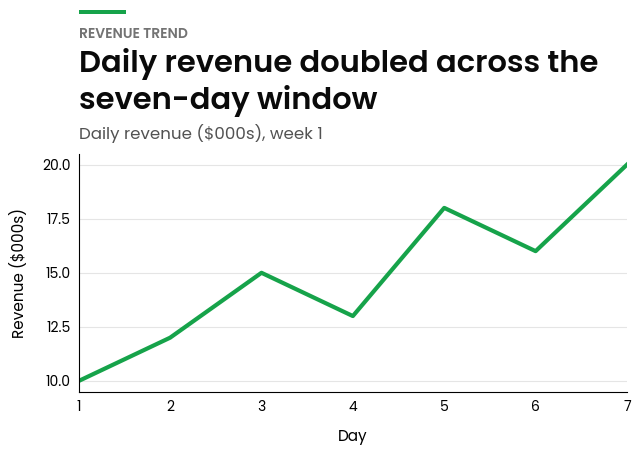

In [ ]:
line.plot(
    daily_revenue,
    x_col="day",
    value_col="revenue",
    eyebrow="Revenue trend",
    title="Daily revenue doubled across the seven-day window",
    subtitle="Daily revenue ($000s), week 1",
    x_label="Day",
    y_label="Revenue ($000s)",
)
plt.show()

## Plotting a Pandas Series

A `Series` works directly: the function uses the index as the x-axis and the series name as the line label. Useful when the upstream computation (e.g. a `groupby().sum()`) already returns a Series and you don't want to wrap it just to plot. When passing a Series, leave `value_col`, `x_col`, and `group_col` all as `None`.

---

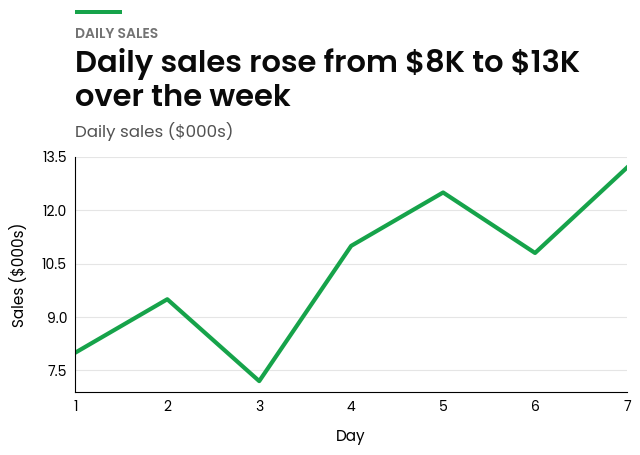

In [ ]:
line.plot(
    daily_sales_series,
    eyebrow="Daily sales",
    title=r"Daily sales rose from \$8K to \$13K over the week",
    subtitle="Daily sales ($000s)",
    x_label="Day",
    y_label="Sales ($000s)",
)
plt.show()

## Multiple Lines with `group_col`

Pass `group_col` to draw one line per category from a *long-format* DataFrame. The function pivots the data internally and assigns a colour per group. Pick this shape when each row is a single observation of (x, group, value), as you'd get from a SQL `GROUP BY` query.

---

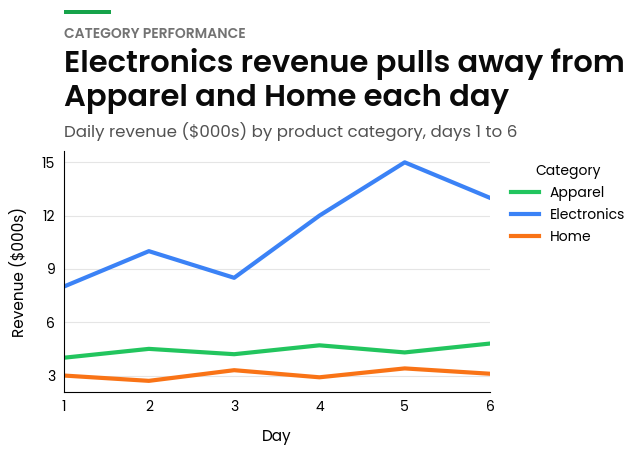

In [ ]:
line.plot(
    category_revenue,
    x_col="day",
    value_col="revenue",
    group_col="category",
    eyebrow="Category performance",
    title="Electronics revenue pulls away from Apparel and Home each day",
    subtitle="Daily revenue ($000s) by product category, days 1 to 6",
    x_label="Day",
    y_label="Revenue ($000s)",
    legend_title="Category",
    move_legend_outside=True,
)
plt.show()

## Multiple Value Columns

If the data is already in *wide format* (one column per series), pass a list to `value_col` instead of using `group_col`. The two are mutually exclusive: passing both raises `ValueError`. A real risk worth flagging: when the series have very different magnitudes, the small ones get squashed against the x-axis on a shared y-scale, as happens here with revenue versus visitor count.

---

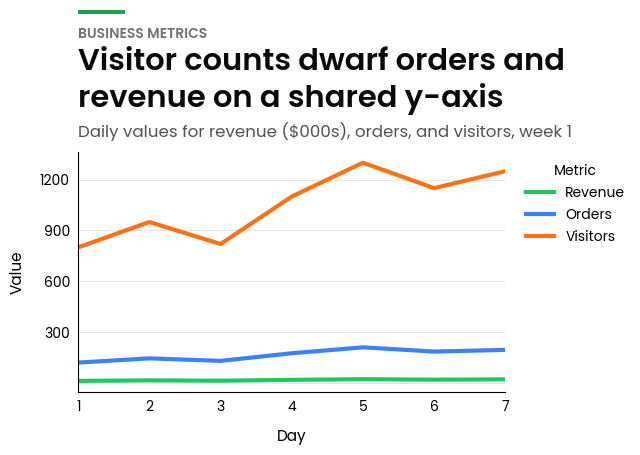

In [ ]:
line.plot(
    metrics_data,
    x_col="day",
    value_col=["Revenue", "Orders", "Visitors"],
    eyebrow="Business metrics",
    title="Visitor counts dwarf orders and revenue on a shared y-axis",
    subtitle="Daily values for revenue ($000s), orders, and visitors, week 1",
    x_label="Day",
    y_label="Value",
    legend_title="Metric",
    move_legend_outside=True,
)
plt.show()

## Index-Based Plotting

Omit `x_col` and the function uses the DataFrame's index as the x-axis. Convenient when the index already carries the meaning, like a `CategoricalIndex` of trading weeks or a `DatetimeIndex` of trading days. The visible data and the underlying DataFrame stay perfectly aligned without an extra column.

---

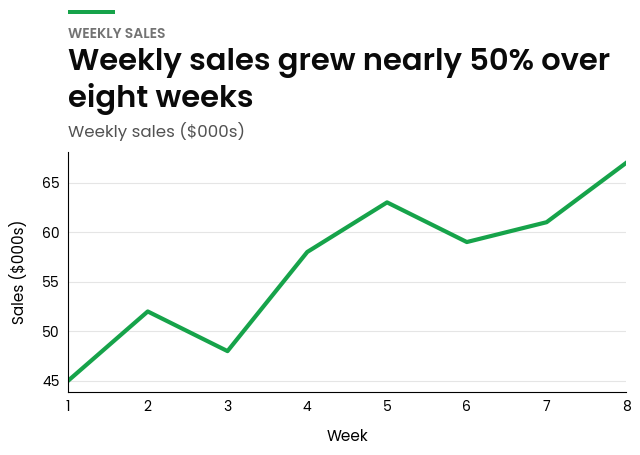

In [ ]:
line.plot(
    weekly_sales,
    value_col="sales",
    eyebrow="Weekly sales",
    title="Weekly sales grew nearly 50% over eight weeks",
    subtitle="Weekly sales ($000s)",
    x_label="Week",
    y_label="Sales ($000s)",
)
plt.show()

## Fill Missing Values

When `group_col` triggers an internal pivot, any missing (x, group) combination becomes a `NaN` and the line breaks. Pass `fill_na_value` to substitute a fixed value (typically `0`) so the lines stay continuous. Use this when the missing periods genuinely mean "zero", and skip it when a gap should remain visible.

---

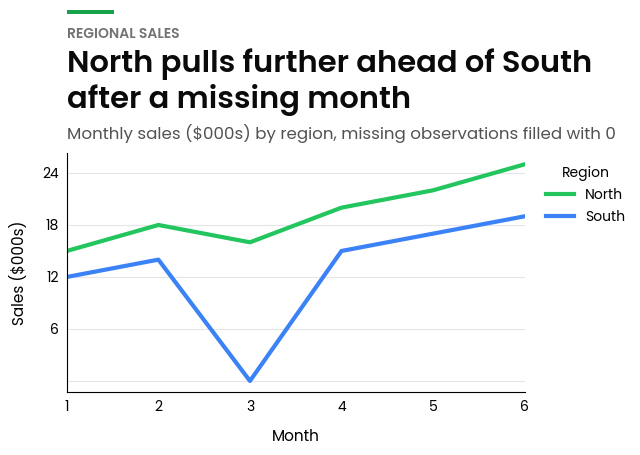

In [ ]:
line.plot(
    regional_sparse,
    x_col="month",
    value_col="sales",
    group_col="region",
    fill_na_value=0,
    eyebrow="Regional sales",
    title="North pulls further ahead of South after a missing month",
    subtitle="Monthly sales ($000s) by region, missing observations filled with 0",
    x_label="Month",
    y_label="Sales ($000s)",
    legend_title="Region",
    move_legend_outside=True,
)
plt.show()

## Highlighting Specific Lines

Pass `highlight=[...]` to keep a few series in saturated colour while muting the rest to grey. Pick this when there are too many lines to read individually but the analysis is about a specific subset (a competitive set, a watchlist, an underperforming group). The muted lines stay as context so the reader can see whether the highlighted subset is moving with or against the pack.

---

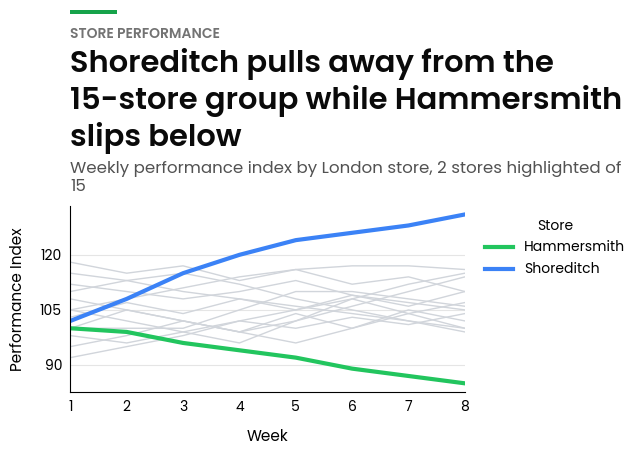

In [ ]:
line.plot(
    store_performance,
    x_col="week",
    value_col="performance",
    group_col="store_name",
    highlight=["Shoreditch", "Hammersmith"],
    eyebrow="Store performance",
    title="Shoreditch pulls away from the 15-store group while Hammersmith slips below",
    subtitle="Weekly performance index by London store, 2 stores highlighted of 15",
    x_label="Week",
    y_label="Performance Index",
    legend_title="Store",
    move_legend_outside=True,
)
plt.show()

## End-of-Line Legend

Pass `legend_style="end_of_line"` to suppress the boxed legend and place a colored series label at the right end of each line instead. The label sits next to the data it describes, so the reader doesn't bounce between a legend swatch and a line. Works best with three to five series, more than that and the labels start to crowd each other.

---

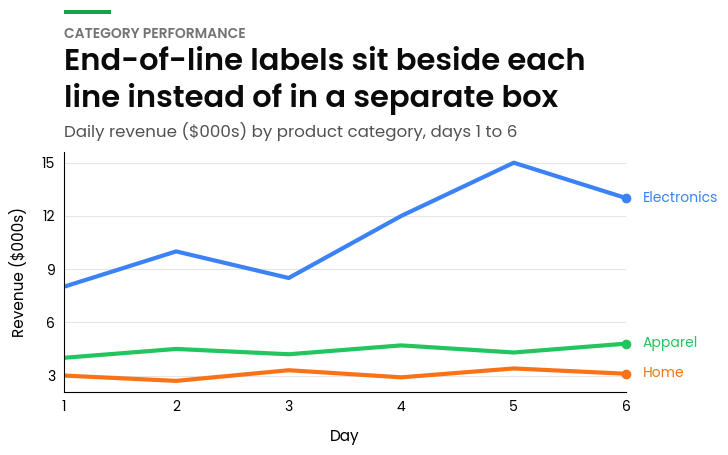

In [ ]:
line.plot(
    category_revenue,
    x_col="day",
    value_col="revenue",
    group_col="category",
    legend_style="end_of_line",
    eyebrow="Category performance",
    title="End-of-line labels sit beside each line instead of in a separate box",
    subtitle="Daily revenue ($000s) by product category, days 1 to 6",
    x_label="Day",
    y_label="Revenue ($000s)",
)
plt.show()